#Часть 1. Доделываем семинар и получаем SNP

In [ ]:
#Начальные этапы семинара
conda create -n genome_alignment python=3.9 numpy pandas matplotlib biopython
conda activate genome_alignment
conda install -c bioconda mummer last
# Создаем директорию там где вы находитесь сейчас, может это папка биоинформатика или загрузки
mkdir -p genome_alignment_prac/{data,scripts,results}
cd genome_alignment_prac

# Скачиваем геномы
cd data
wget -O ecoli_k12.fna.gz \
  "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.fna.gz"
wget -O ecoli_o157.fna.gz \
  "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/008/865/GCF_000008865.2_ASM886v2/GCF_000008865.2_ASM886v2_genomic.fna.gz"
gunzip *.fna.gz

# Анализ структуры геномов
echo "=== E. coli K-12 ==="
grep ">" ecoli_k12.fna | wc -l
grep ">" ecoli_k12.fna

echo "=== E. coli O157:H7 ==="
grep ">" ecoli_o157.fna | wc -l
grep ">" ecoli_o157.fna

cd ../results

# Полное выравнивание без фильтрации
nucmer --prefix=ecoli_full ../data/ecoli_k12.fna ../data/ecoli_o157.fna

# Оптимизированное выравнивание
# --maxmatch: искать все совпадения, не только уникальные
# --mincluster=100: минимальная длина кластера
# --diagfactor=0.12: фактор диагонали для кластеризации
nucmer --prefix=ecoli_opt --maxmatch --mincluster=100 --diagfactor=0.12 \
    ../data/ecoli_k12.fna ../data/ecoli_o157.fna
# Различные стратегии фильтрации
# 1. 1-to-1 выравнивание с высокой идентичностью
delta-filter -1 -i 90 ecoli_full.delta > ecoli_full_filt1.delta

# 2. 1-to-1 с минимальной длиной 5000 bp
delta-filter -1 -l 5000 ecoli_full.delta > ecoli_full_filt2.delta

# 3. Множественные выравнивания (для поиска дупликаций)
delta-filter -m -i 85 ecoli_full.delta > ecoli_full_multi.delta

# Статистика
echo "=== Фильтр 1 (1-to-1, id>90%) ==="
show-coords -r ecoli_full_filt1.delta | wc -l

echo "=== Фильтр 2 (1-to-1, len>5kb) ==="
show-coords -r ecoli_full_filt2.delta | wc -l

Были написаны 2 скрипта для визуализации: plot_histograms.py и plot_snp_density.py и получены следующие визуализации

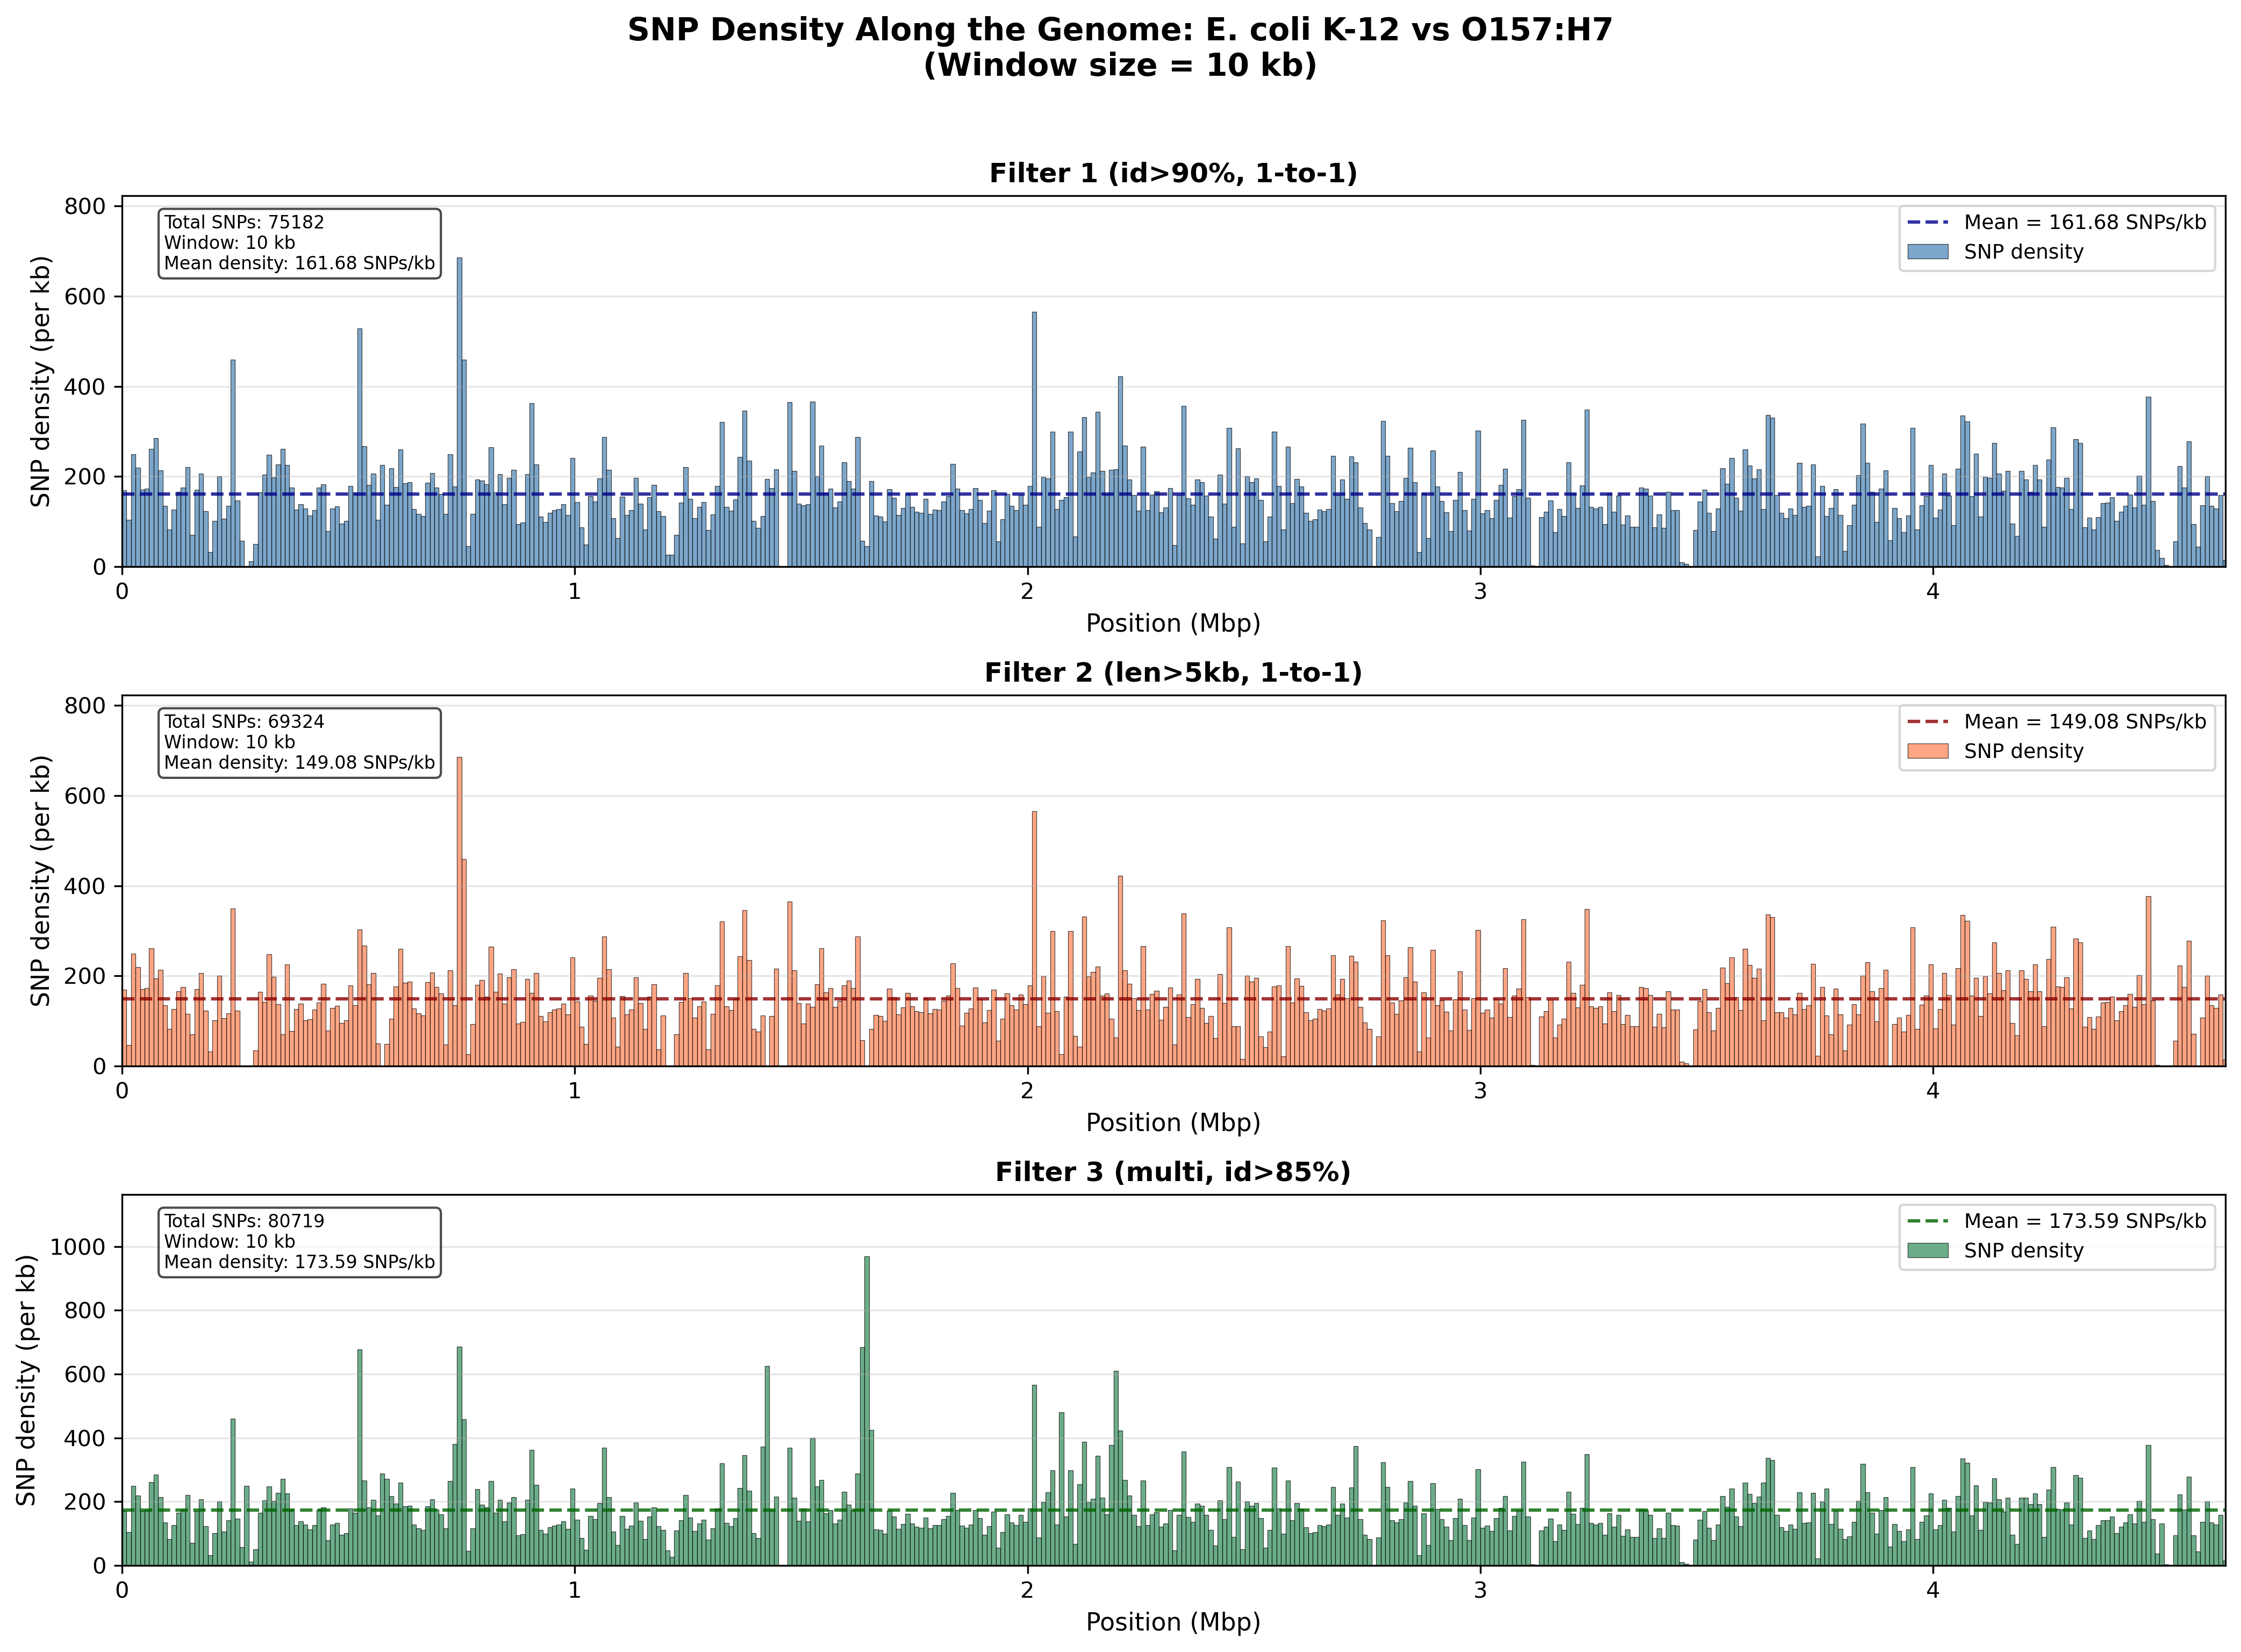


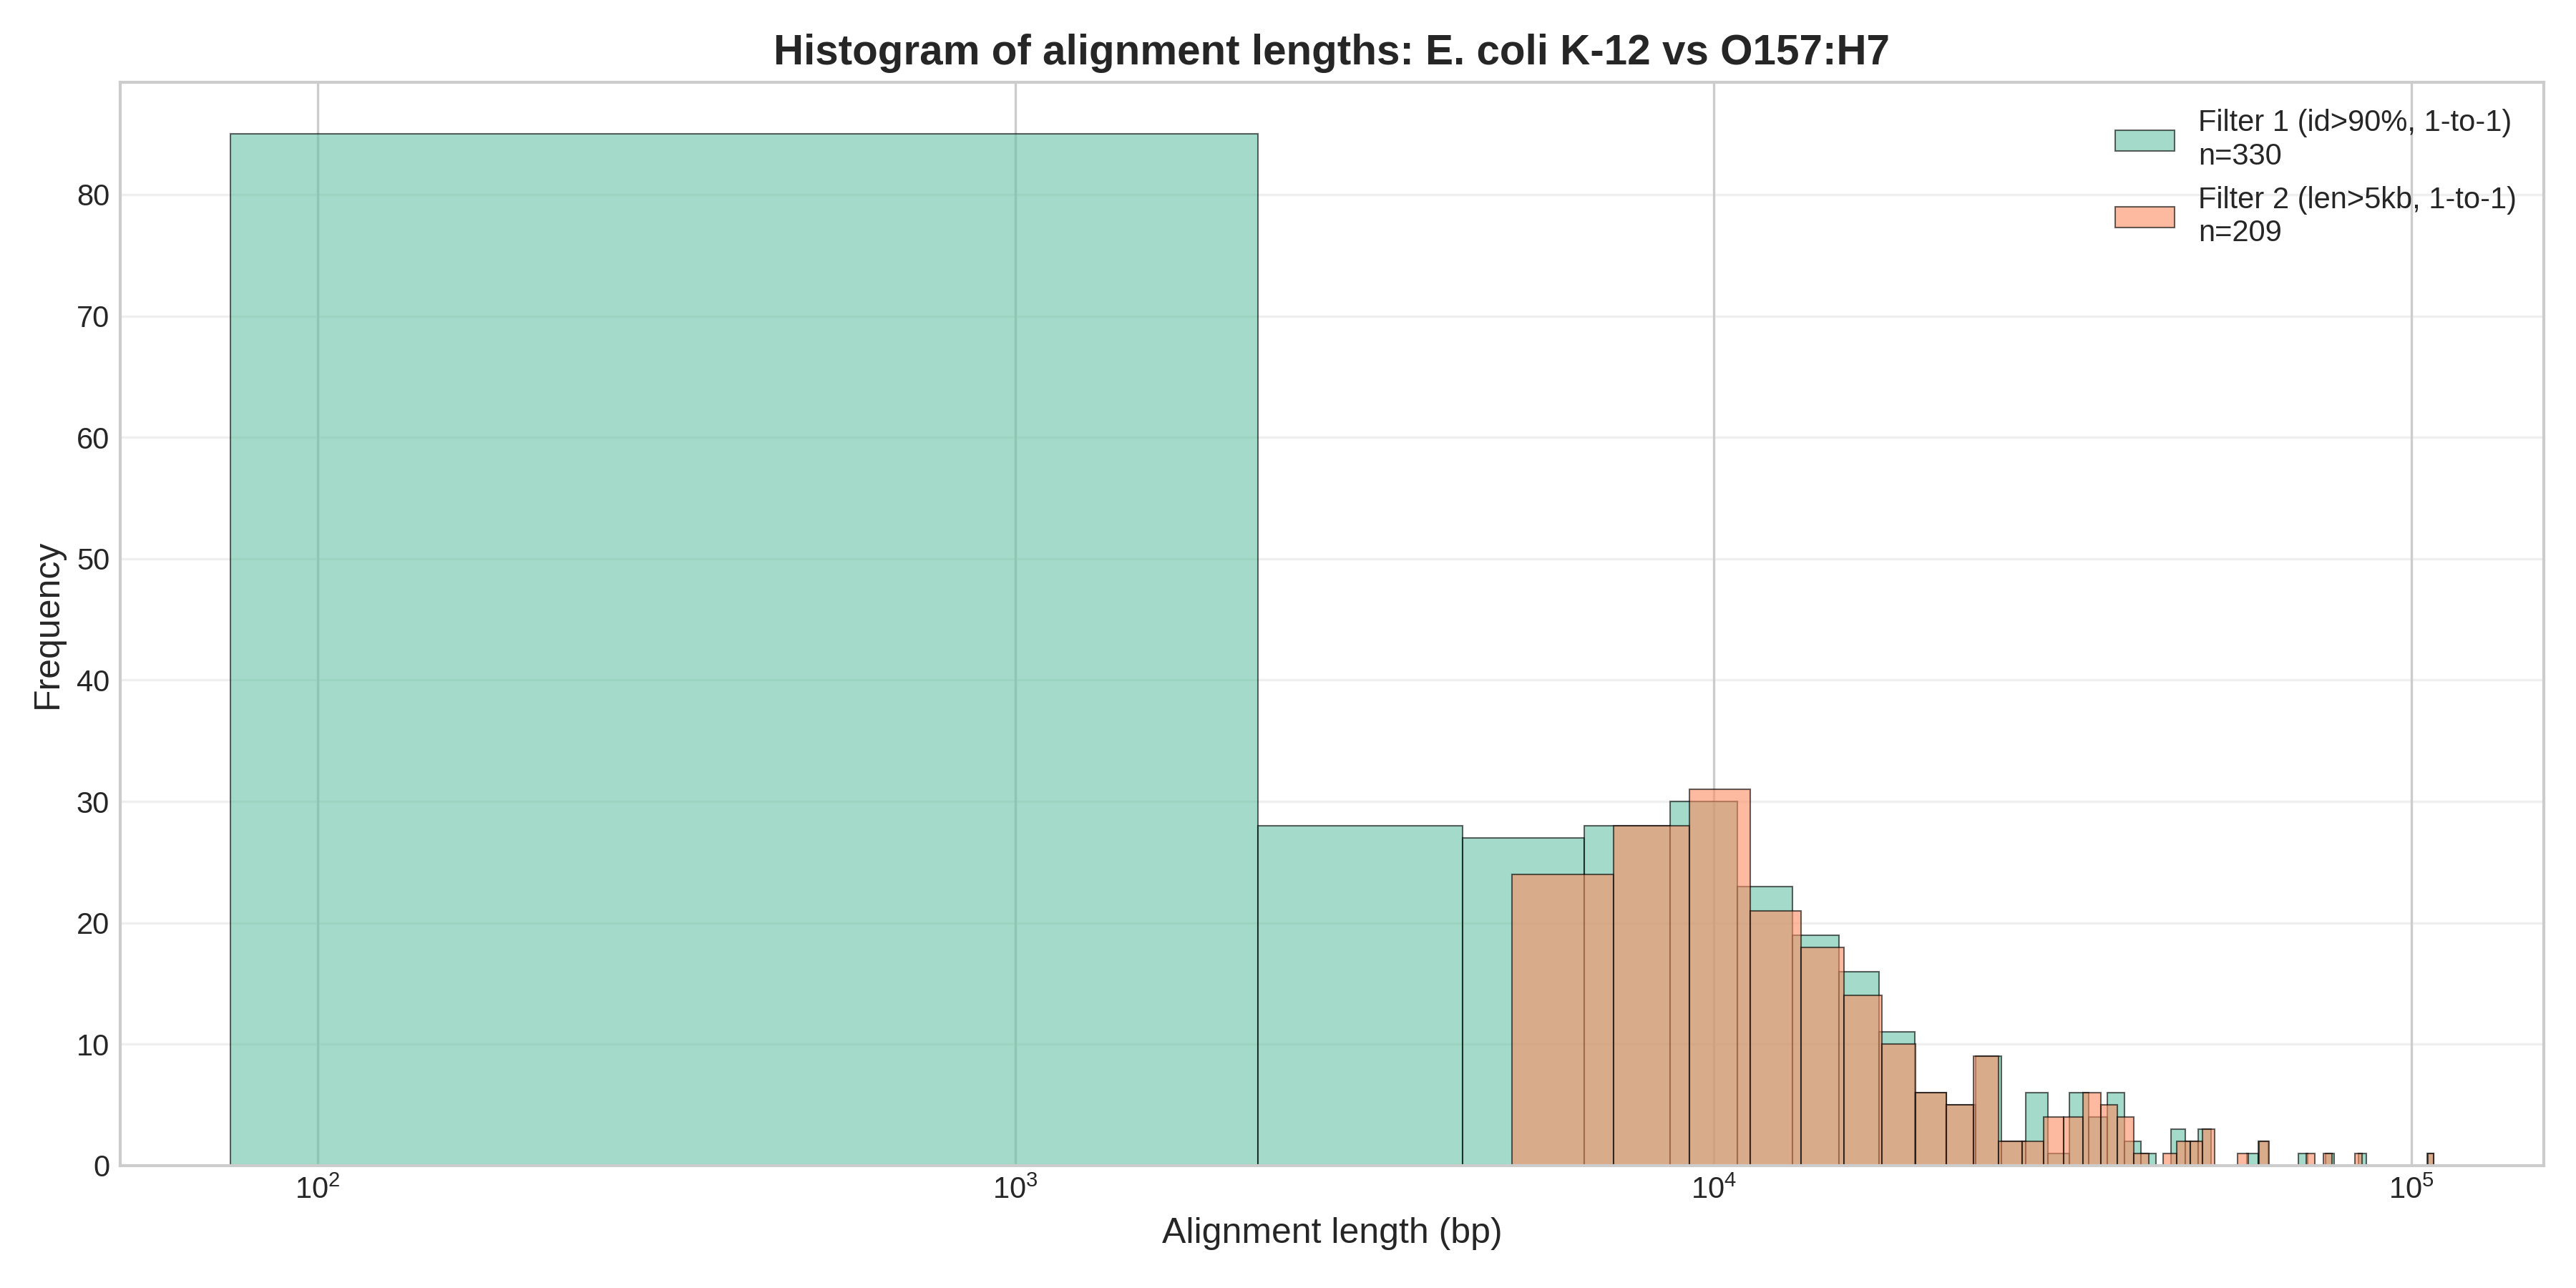

Также получили текстовый файл с SNP для оптимизированного варианта выравнивания (ecoli_opt.delta):


```
show-snps -C -r ecoli_opt.delta > ecoli_snps_for_report.txt
```






После чего вывели шапку:


```
head -20 ecoli_snps_for_report.txt
```

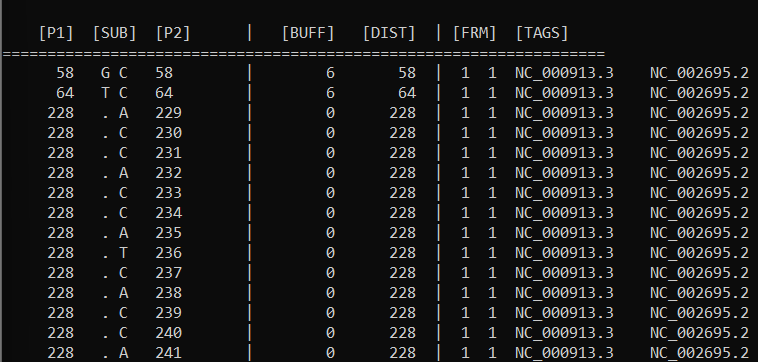

**Описание столбцов:**

*   [P1] - координата нуклеотида в референсном геноме (ecoli_k-12.fna)
*   [SUB] - нуклеотидная замена(точка означает gap)
*   [P2] - координата нуклеотида в референсном геноме query (ecoli_o157.fna)
*   [BUFF] - расстояние до предыдущего SNP
*   [DIST] - расстояние от начала текущего выравниваемого фрагмента до позиции SNP
*   [FRM] - ориентация референса, ориентация query и номер кластера (фрагмента) выравнивания
*   [TAGS] - accession‑номера геномов, из которых взяты последовательности









# Часть 2 — Аннотация SNP

Был написан скрипт annotate_snps.py, который загружает SNP файл, загружает аннотацию генов (используйте GenBank файл E. coli K-12), и для каждого SNP определяет:

*   В каком гене находится (или межгенный регион)
*   Тип SNP (синонимичный/несинонимичный, если в CDS)
*   Изменение аминокислоты (например, p.Ser83Leu)
*   Потенциальное функциональное значение

Скрипт приведен ниже:

Предварительно скачали GenBank в папку results:

```
wget https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.gbff.gz
gunzip GCF_000005845.2_ASM584v2_genomic.gbff.gz
mv GCF_000005845.2_ASM584v2_genomic.gbff ecoli_k12.gb
```



In [ ]:
import pandas as pd
from Bio import SeqIO
from Bio.Seq import Seq
import matplotlib.pyplot as plt
from collections import defaultdict

#загрузка SNP из NUCMER‑файла
def load_snps(path):
    snps = []
    #пропускаем, все что не SNP
    with open(path) as f:
        for line in f:
            line = line.strip()
            if (
                line.startswith("/") or
                line.startswith("NUCMER") or
                line.startswith("[") or
                line.startswith("=") or
                line == ""
            ):
                continue
            #фильтруем строки, которые похожи на SNP, но не SNP
            parts = line.split()
            #колонок меньше трех
            if len(parts) < 3:
                continue

            #первая колонка не число
            try:
                P1 = int(parts[0])
            except ValueError:
                continue  #если вдруг встретится мусор

            ref_nt = parts[1]#записываем нуклеотид референса
            alt_nt = parts[2]#записываем нуклеотид альтернативы(query)

            snps.append((P1, ref_nt, alt_nt))#добавляем к SNP позицию нуклеотида, нуклеотид референса, нуклеотид альтернативы(query)

    #возвращаем таблицу SNP
    df = pd.DataFrame(snps, columns=["pos", "ref", "alt"])
    return df

snp_df = load_snps("ecoli_snps_for_report.txt")#все SNP, найденные NUCMER

#загружаем GenBank K‑12
gb_record = SeqIO.read("ecoli_k12.gb", "genbank")
genome_seq = gb_record.seq

#извлекаем все CDS из GenBank
genes = []
for feat in gb_record.features:
    if feat.type == "CDS":
        start = int(feat.location.start)#начало гена
        end = int(feat.location.end)#конец гена
        strand = feat.location.strand#направление
        gene = feat.qualifiers.get("gene", ["unknown"])[0]#название гена
        product = feat.qualifiers.get("product", ["unknown"])[0]#белковый продукт
        genes.append((start, end, strand, gene, product))

genes_df = pd.DataFrame(genes, columns=["start", "end", "strand", "gene", "product"])

#Функция поиска гена по координате SNP
#Если SNP попадает в CDS, то возвращается строка с информацией о гене
#Если нет, то возвращаем None
def find_gene(pos):
    hits = genes_df[(genes_df.start <= pos) & (genes_df.end >= pos)]
    if len(hits) == 0:
        return None
    return hits.iloc[0]

#Классифицируем SNP внутри гена
def classify_snp(gene_row, pos, ref, alt):
    if ref == "." or alt == ".":
        return "indel", None

    #если SNP межгенный
    if gene_row is None:
        return "intergenic", None

    #определение положения SNP внутри CDS
    start, end, strand, gene, product = gene_row

    cds_pos = pos - start
    if strand == -1:
        cds_pos = end - pos
    #определение кодона
    codon_index = cds_pos // 3
    codon_pos = cds_pos % 3

    cds_seq = genome_seq[start:end]
    if strand == -1:
        cds_seq = cds_seq.reverse_complement()

    codon = list(str(cds_seq[codon_index*3:(codon_index+1)*3]))

    #если кодон неполный - пропускаем
    if len(codon) != 3:
        return "partial", None

    codon[codon_pos] = alt#заменяем нуклеотид

    new_codon = "".join(codon)

    #переводим кодоны в аминокислоты
    try:
        aa_old = str(Seq("".join(codon)).translate())
        aa_new = str(Seq(new_codon).translate())
    except:
        return "invalid", None

    #определяем тип SNP
    if aa_old == aa_new:
        snp_type = "synonymous"
    else:
        snp_type = "nonsynonymous"

    aa_change = f"p.{aa_old}{codon_index+1}{aa_new}"

    return snp_type, aa_change

#АННОТАЦИЯ SNP
annot_gene = []
annot_type = []
annot_aa = []
annot_product = []

for i, row in snp_df.iterrows():
    pos, ref, alt = row["pos"], row["ref"], row["alt"]

    gene_row = find_gene(pos)
    if gene_row is None:
        annot_gene.append("intergenic")
        annot_type.append("intergenic")
        annot_aa.append(None)
        annot_product.append(None)
        continue

    gene = gene_row.gene
    product = gene_row.product

    snp_type, aa_change = classify_snp(gene_row, pos, ref, alt)

    annot_gene.append(gene)
    annot_type.append(snp_type)
    annot_aa.append(aa_change)
    annot_product.append(product)

snp_df["gene"] = annot_gene
snp_df["type"] = annot_type
snp_df["aa_change"] = annot_aa
snp_df["product"] = annot_product

#проводим функциональную интерпретацию
def functional_effect(row):
    if row["type"] == "intergenic":
        return "likely regulatory"
    if row["type"] == "synonymous":
        return "likely neutral"
    if row["type"] == "nonsynonymous":
        return "possible functional impact"
    return "unknown"

snp_df["effect"] = snp_df.apply(functional_effect, axis=1)

snp_df.to_csv("annotated_snps.csv", index=False)#сохраняем итоговую таблицу

#ГРАФИК ПЛОТНОСТИ SNP
plt.figure(figsize=(14, 4))
plt.hist(snp_df["pos"], bins=200, color="steelblue")
plt.title("SNP density along genome")
plt.xlabel("Genome position")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("snp_density_final.png", dpi=300)

#ГИСТОГРАММА РАСПРЕДЕЛЕНИЯ ТИПОВ SNP
plt.figure(figsize=(6, 4))
snp_df["type"].value_counts().plot(kind="bar", color="darkred")
plt.title("Distribution of SNP types")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("snp_types.png", dpi=300)

#ПОЛУЧАЕМ ТОП 10 ГЕНОВ
top10 = (
    snp_df[snp_df.gene != "intergenic"]
    .groupby("gene")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top10.to_csv("top10_genes.csv")
print("Top-10 genes saved to top10_genes.csv")

ModuleNotFoundError: No module named 'Bio'

Полученный график плотности SNP с наложением позиций генов:
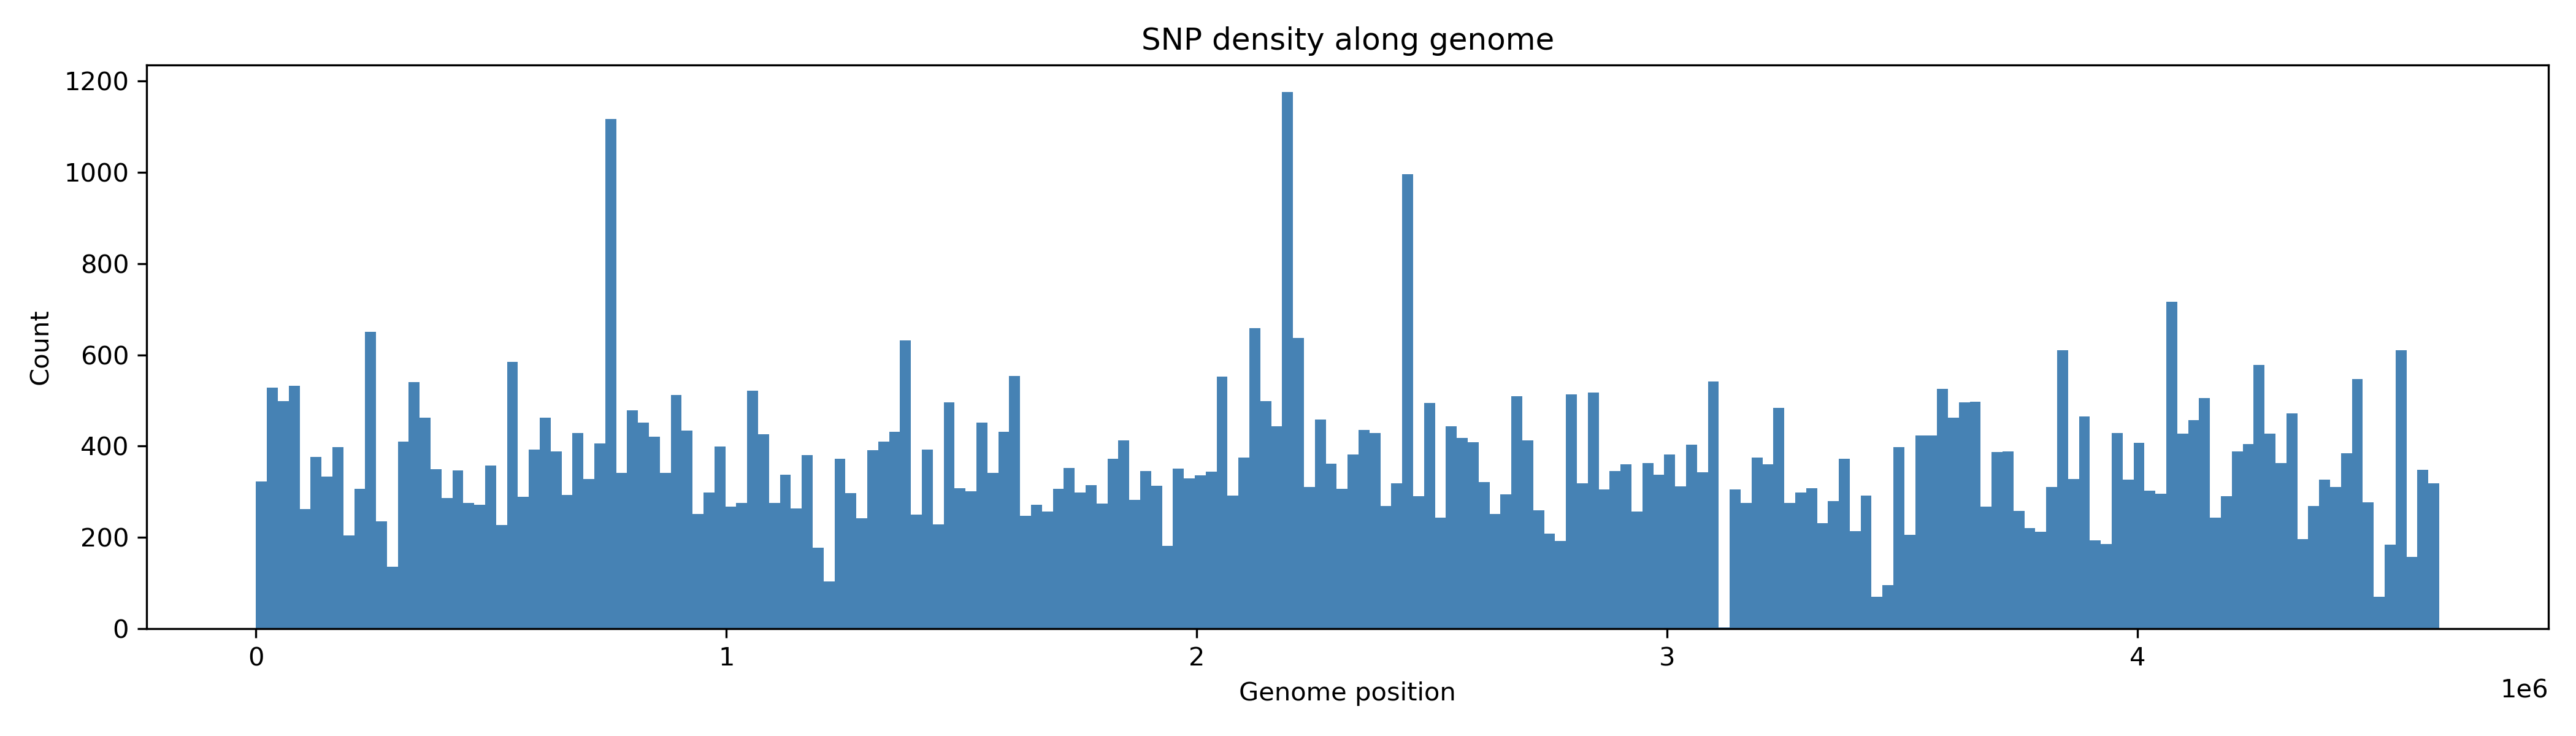

Полученная гистограмма распределения типов SNP:
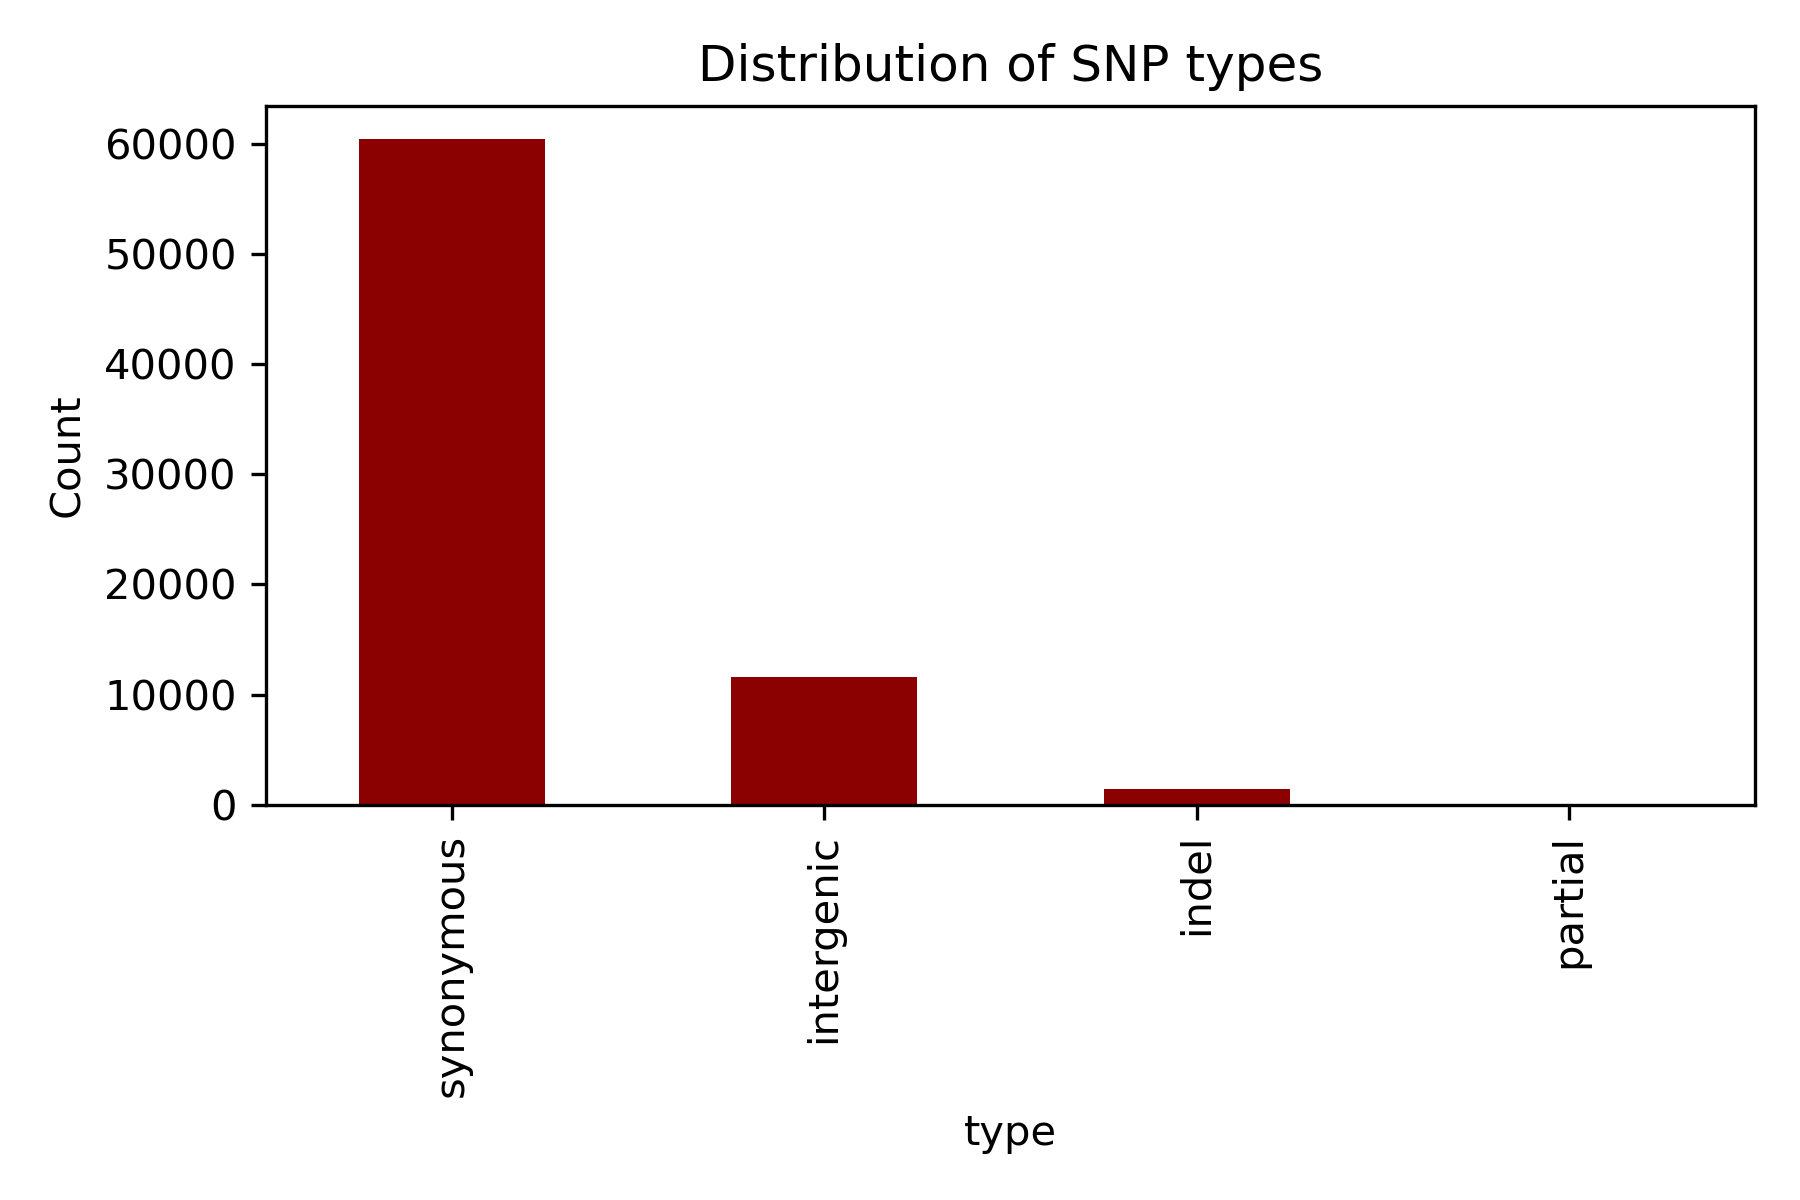

Заметим, что тут нет несинонимичных замен, что скорее всего связано с аннотацией по штамму К12 (как вроде и просится в задании), а не по штамму O157, SNP, которые в O157 дают замену аминокислоты,
в координатах K-12 могут попадать вообще в другой кодон, в синонимичную позицию, в межгенный регион или вообще в другой ген.

Топ 10 генов:


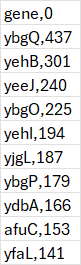



#Часть 3. Поиск функционально значимых SNP

Попробуем идентифицировать мутаций в генах устойчивости к антибиотикам

Создали файл со списком генов устойчивости ar_genes.txt в папке results, куда вставили гены, мутации в которых должны привести к устойчивочти к антибиотикам, информацию о которых нашли в статьях.

Создали скрипт extract_ar_snps.py для вытаскивания SNP:

In [ ]:
import pandas as pd

#ЗАГРУЗКА ДАННЫХ
print("Загрузка файлов...")

#загружаем аннотированные SNP
df = pd.read_csv("annotated_snps.csv")
print(f"  Всего SNP: {len(df)}")

#загружаем список генов устойчивости (пропускаем пустые строки и комментарии)
ar_genes = []
with open("ar_genes.txt") as f:
    for line in f:
        line = line.strip()
        if line and not line.startswith("#"):
            ar_genes.append(line.lower())  #приводим к нижнему регистру для поиска

print(f"  Генов в списке: {len(ar_genes)}")

#ПОИСК SNP В ГЕНАХ УСТОЙЧИВОСТИ
print("\nПоиск SNP в генах устойчивости...")

#приводим колонку с генами к нижнему регистру для сравнения
df["gene_lower"] = df["gene"].str.lower()

#фильтруем: ген должен быть в списке и не NaN
ar_snps = df[df["gene_lower"].isin(ar_genes) & df["gene"].notna()]

#удаляем временную колонку
ar_snps = ar_snps.drop("gene_lower", axis=1)

print(f"  Найдено SNP: {len(ar_snps)}")

#РАЗДЕЛЕНИЕ ПО ТИПАМ
ar_nonsyn = ar_snps[ar_snps["type"] == "nonsynonymous"]
ar_syn = ar_snps[ar_snps["type"] == "synonymous"]
ar_indel = ar_snps[ar_snps["type"] == "indel"]

print(f"    - несинонимичных: {len(ar_nonsyn)}")
print(f"    - синонимичных: {len(ar_syn)}")
print(f"    - инделов: {len(ar_indel)}")

#СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
print("\nСохранение результатов...")

ar_snps.to_csv("ar_all_snps.csv", index=False)
ar_nonsyn.to_csv("ar_nonsyn_snps.csv", index=False)

print("  ar_all_snps.csv - все SNP в генах устойчивости")
print("  ar_nonsyn_snps.csv - только несинонимичные замены")

#ВЫВОД В КОНСОЛЬ
print("\n" + "="*50)
if len(ar_nonsyn) > 0:
    print("НЕСИНОНИМИЧНЫЕ ЗАМЕНЫ В ГЕНАХ УСТОЙЧИВОСТИ:")
    print("="*50)

    cols = ["pos", "gene", "aa_change", "product"]
    for _, row in ar_nonsyn.iterrows():
        print(f"\nГен: {row['gene']}")
        print(f"  Позиция в геноме: {row['pos']}")
        print(f"  Замена: {row['aa_change']}")
        print(f"  Продукт: {row['product']}")
else:
    print("РЕЗУЛЬТАТ:")
    print("  Несинонимичных замен в генах устойчивости не обнаружено")
    print("  Штамм вероятно сохраняет чувствительность к антибиотикам")
print("="*50)


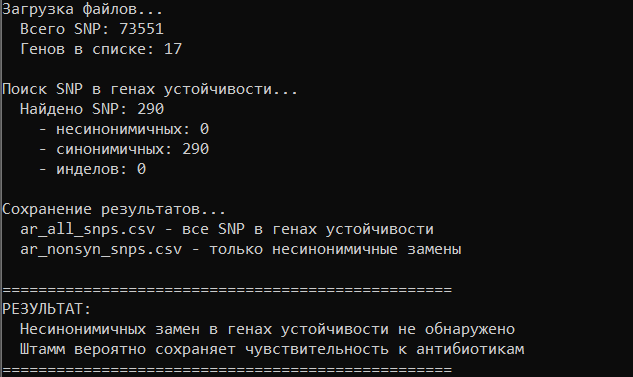

Вообще в силу разных размеров геномов и координатах в них такой анализ наверное, делать некорректно, так как координаты относительно к12 по которым мы и смотрим не совпадают с возможными мутациями антибиотиуорезистентности в о157, так как они по идее просто находятся в другом месте

Заметим, что несинонимичных замен не обнаружено, что может указывать на то, что штамм сохраняет чувствительность к антибиотиком, что в целом верно для лабораторного штамма K-12, для которого и проводилась аннотация. Также это, возможно, происходит, потому что гены-мишени основных классов антибиотиков находятся под
сильным очищающим отбором и не накапливают несинонимичных замен
даже при значительной эволюционной дивергенции штаммов.


Сделаем более корректное сравнение геномов, которое будет сравнивать не по позиции, а по гену. Скрипт compare_refs.py представлен ниже:

In [ ]:
from Bio import SeqIO
from Bio.Seq import Seq
import pandas as pd

#ЗАГРУЗКА ДАННЫХ
print("Загрузка K-12...")
k12 = SeqIO.read("ecoli_k12.gb", "genbank")
print("Загрузка O157:H7...")
o157 = SeqIO.read("ecoli_o157.gb", "genbank")

def extract_proteins(gb_record):
    """Извлекает все белки из GenBank записи"""
    proteins = {}
    for feat in gb_record.features:
        if feat.type == "CDS":
            #получаем ген и продукт
            gene = feat.qualifiers.get("gene", ["unknown"])[0]
            product = feat.qualifiers.get("product", ["unknown"])[0]

            #получаем белковую последовательность
            if "translation" in feat.qualifiers:
                protein_seq = feat.qualifiers["translation"][0]
                proteins[gene] = {
                    "product": product,
                    "sequence": protein_seq,
                    "location": f"{int(feat.location.start)}-{int(feat.location.end)}"
                }
    return proteins

#извлекаем белки из обоих геномов
k12_proteins = extract_proteins(k12)
o157_proteins = extract_proteins(o157)

print(f"Найдено белков в K-12: {len(k12_proteins)}")
print(f"Найдено белков в O157:H7: {len(o157_proteins)}")

#АНАЛИЗ РАЗЛИЧИЙ
results = []

#уникальные гены O157 (нет в K-12)
o157_unique = set(o157_proteins.keys()) - set(k12_proteins.keys())
print(f"\nУникальных генов в O157:H7: {len(o157_unique)}")

for gene in o157_unique:
    results.append({
        "gene": gene,
        "type": "UNIQUE_TO_O157",
        "product": o157_proteins[gene]["product"],
        "location_o157": o157_proteins[gene]["location"],
        "aa_changes": "GENE_ABSENT_IN_K12"
    })

#уникальные гены K-12 (нет в O157)
k12_unique = set(k12_proteins.keys()) - set(o157_proteins.keys())
print(f"Уникальных генов в K-12: {len(k12_unique)}")

for gene in k12_unique:
    results.append({
        "gene": gene,
        "type": "UNIQUE_TO_K12",
        "product": k12_proteins[gene]["product"],
        "location_o157": "N/A",
        "aa_changes": "GENE_ABSENT_IN_O157"
    })

#общие гены с различиями
common_genes = set(k12_proteins.keys()) & set(o157_proteins.keys())
print(f"Общих генов: {len(common_genes)}")

nonsyn_count = 0
for gene in common_genes:
    k12_seq = k12_proteins[gene]["sequence"]
    o157_seq = o157_proteins[gene]["sequence"]

    if k12_seq != o157_seq:
        #находим позиции различий
        changes = []
        for i, (aa_k12, aa_o157) in enumerate(zip(k12_seq, o157_seq)):
            if aa_k12 != aa_o157:
                changes.append(f"p.{aa_k12}{i+1}{aa_o157}")

        #определяем тип изменений
        if len(k12_seq) != len(o157_seq):
            snp_type = "LENGTH_DIFFERENCE"
        else:
            snp_type = "NONSYNONYMOUS"
            nonsyn_count += 1

        results.append({
            "gene": gene,
            "type": snp_type,
            "product": o157_proteins[gene]["product"],
            "location_o157": o157_proteins[gene]["location"],
            "aa_changes": ", ".join(changes) if changes else "LENGTH_MISMATCH"
        })

print(f"Общих генов с несинонимичными заменами: {nonsyn_count}")

#СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
df = pd.DataFrame(results)

#сохраняем полный отчет
df.to_csv("k12_vs_o157_comparison.csv", index=False)

#отдельно сохраняем уникальные гены O157 (важные для патогенности!)
o157_unique_df = df[df["type"] == "UNIQUE_TO_O157"]
o157_unique_df.to_csv("o157_unique_genes.csv", index=False)

#отдельно сохраняем гены с мутациями
mutated_df = df[df["type"] == "NONSYNONYMOUS"]
mutated_df.to_csv("o157_mutations.csv", index=False)

#ВЫВОД СТАТИСТИКИ
print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ K-12 vs O157:H7")
print("="*50)
print(f"Уникальные гены O157:H7 (патогенность, токсины): {len(o157_unique)}")
print(f"Гены с несинонимичными заменами: {nonsyn_count}")
print(f"Гены, отсутствующие в O157:H7: {len(k12_unique)}")
print("\nТоп-10 уникальных генов O157:H7:")
for gene in list(o157_unique)[:10]:
    print(f"  - {gene}: {o157_proteins[gene]['product'][:60]}...")

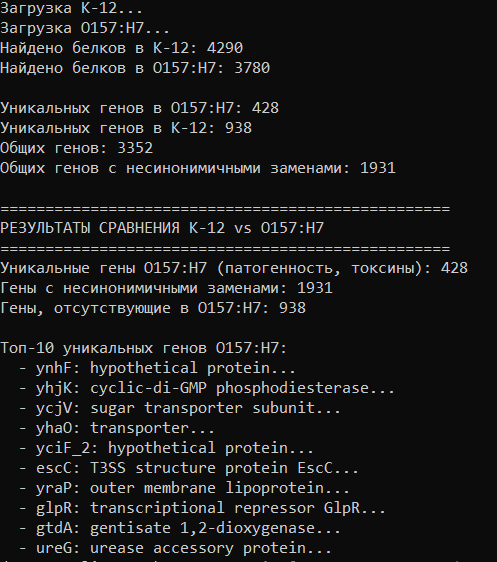

И вот тут уже несинонимичные замены по генам найдены и записаны в отдельный файл o157_mutations.csv

##Зачем вообще идентифицировать SNP в генах устойчивочти к антибиотику?

1. Если бы у нас были несинонимичные замены, то секвенирование и их обнаружение в посеве бактерий пациента, например, могло бы показать, что к данным конкретным антибиотикам бактерия скорее всего резистентна и их не стоит использовать, в то время как для других таких замен нет, а значит они применимы.

2. По ним можно было бы понять как именно бактерия защищается от антибиотика и разрабатывает новый

3. Это также можно использовать для разработки новых лекарств, знаем SNP мишени - модифицируем нерабочий антибиотик, основываясб на этих знаниях.

4. Наверное, по несинонимичным заменам можно отслеживать вспышки инфекций, а также их путь распросранения, бактерии с одной и той же несинонимичной специфической заменой скорее всего произошли от одного и того же предка.